# Iterated Fractal Systems

[Moreno Marzolla](https://www.moreno.marzolla.name)

Written in March 2026.

Last modified March 2026.

---

An _affine transformation_ maps a point $(x, y)$ to the new coordinates $(ax + by + e, cx + dy + f)$, where $a, b, c, d, e, f$ are real numbers.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import itertools as it

In [2]:
def affine(p, transformation):
    """
    Transform point `p=(x,y)` according to affine `transformation=(a,b,c,d,e,f)`.
    Return the transformed point `p'=(x',y')`.    
    """
    a, b, c, d, e, f = transformation
    x, y = p
    return (a*x + b*y + e), (c*x + d*y + f)

An _Iterated Fractal System_ (IFS) can be built using a matrix $M \in \mathbb{R}^{P \times 6}$ with $P$ rows and six columns:

\begin{equation*}
M = \left(\begin{matrix}
a_0 & b_0 & c_0 & d_0 & e_0 & f_0 \\
a_1 & b_1 & c_1 & d_1 & e_1 & f_1 \\
\ldots \\
a_{P-1} & b_{P-1} & c_{P-1} & d_{P-1} & e_{P-1} & f_{P-1}
\end{matrix}\right)
\end{equation*}

To draw an IFS we start with a random point $p_0$ in the unitary square; then, at each step we transform the last point $p_k$ with a random affine transformation from $M$ to get $p_{k+1}$. At the end of this process, we get a sequence of $n$ points $p_0, p_1, \ldots, p_{n-1}$ that represent the orbit of $p_0$ under repeated application of a random affine transformation. We draw all points, and start again with a new random initial point. 

In [3]:
def apply_random_rule(p, rule):
    """
    Applies a random transformation from `rule` to point `p`.
    `rule` must be a rectangular matrix with six columns; each row
    is a transformation.
    """
    n = len(rule)
    ruleno = np.random.choice(n)
    return affine(p, rule[ruleno])

def iterate(f, p):
    """
    Generates the infinite orbit of point `p` under repeated application of function `f`.
    """
    while True:
        yield(p)
        p = f(p)

def orbit(f, p0, n):
    """
    Return the first `n` points of the orbit of `p0` under repeated application of function `f`.
    In other words, return the sequence p0, f(p0), f(f(p0)), ...
    """
    return list(it.islice(iterate(f, p0), n))

def IFS(rule, norbits=100, points_per_orbit=1000):
    for _ in range(norbits):
        p0 = np.random.rand(2)
        points = orbit(lambda p: apply_random_rule(p, rule), p0, points_per_orbit)
        x, y = zip(*points)
        plt.plot(list(x), list(y), '.k', ms=0.1)
    plt.show()

The following matrices are suggested by Gary William Flake, "The Computational Beauty of Nature", chapter 7 _Affine Transformations_.

In [4]:
rules1 = [[ 0.0000, -0.5000,  0.5000,  0.0000,  0.5000,  0.0000],
          [ 0.0000,  0.5000, -0.5000,  0.0000,  0.5000,  0.5000],
          [ 0.5000,  0.0000,  0.0000,  0.5000,  0.2500,  0.5000]]

rules2 = [[ 0.7500,  0.0000,  0.0000,  0.7500,  0.1250,  0.1250],
          [ 0.5000, -0.5000,  0.5000,  0.5000,  0.5000,  0.0000],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.0000,  0.7500],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.7500,  0.7500],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.0000,  0.0000],
          [ 0.2500,  0.0000,  0.0000,  0.2500,  0.7500,  0.0000]]

rules3 = [[ 0.3333,  0.0000,  0.0000,  0.5000,  0.0000,  0.0000],
          [ 0.3333,  0.0000,  0.0000,  0.5000,  0.3333,  0.0000],
          [ 0.3333,  0.0000,  0.0000,  0.5000,  0.6667,  0.0000],
          [ 0.3333,  0.0000,  0.0000,  0.5000,  0.6667,  0.5000],
          [-0.3333,  0.0000,  0.0000, -0.5000,  0.6667,  0.5000],
          [-0.3333,  0.0000,  0.0000, -0.5000,  1.0000,  0.5000]]

rules4 = [[ 0.0000,  0.5770, -0.5770,  0.0000,  0.0951,  0.5893],
          [ 0.0000,  0.5770, -0.5770,  0.0000,  0.4413,  0.7893],
          [ 0.0000,  0.5770, -0.5770,  0.0000,  0.0952,  0.9893]]

rules5 = [[ 0.2500,  0.0000,  0.0000,  0.9000,  0.3750,  0.0000],
          [ 0.6500,  0.0000,  0.0000,  0.7500,  0.1750,  0.2500],
          [ 0.0000, -0.5000,  0.2500,  0.0000,  0.5000,  0.2000],
          [ 0.0000,  0.5000, -0.2500,  0.0000,  0.5000,  0.4500]]

rules6 = [[ 0.1950, -0.4880,  0.3440,  0.4430,  0.4431,  0.2453],
          [ 0.4620,  0.4140, -0.2520,  0.3610,  0.2511,  0.5692],
          [-0.0580, -0.0700,  0.4530, -0.1110,  0.5976,  0.0969],
          [-0.0350,  0.0700, -0.4690, -0.0220,  0.4884,  0.5069],
          [-0.6370,  0.0000,  0.0000,  0.5010,  0.8562,  0.2513]]

rules7 = [[ 0.3870,  0.4300,  0.4300, -0.3870,  0.2560,  0.5220],
          [ 0.4410, -0.0910, -0.0090, -0.3220,  0.4219,  0.5059],
          [-0.4680,  0.0200, -0.1130,  0.0150,  0.4000,  0.4000]]

rules8 = [[ 0.5000,  0.0000,  0.0000,  0.7450,  0.2500,  0.0000],
          [ 0.2500, -0.2000,  0.1000,  0.3000,  0.2500,  0.5000],
          [ 0.2500,  0.2000, -0.1000,  0.3000,  0.5000,  0.4000],
          [ 0.2000,  0.0000,  0.0000,  0.3000,  0.4000,  0.5500]]

Let us define a function to draw an IFS.

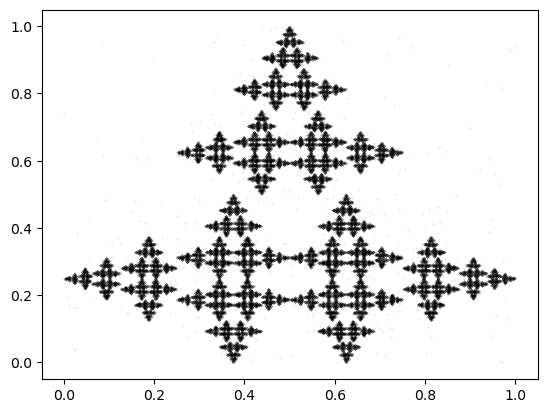

In [5]:
IFS(rules1)

It is quite difficult to understand what an affine transformation does by simply looking at the table of numbers; therefore, we define a function `show_transformation(rules)` that displays `rules` in graphical form. The function scans each row of `rules`, and plot the transformed unitary square.

In [6]:
def show_transformation(rules):
    """
    Graphically show the transformation induced by `rules`.
    `rules` must be a matrix with six columns.
    """
    for r in rules:
        square = np.matrix([affine([0,0], r),
                            affine([0,1], r),
                            affine([1,1], r),
                            affine([1,0], r),
                            affine([0,0], r)])
        x, y = square[:, 0], square[:, 1]
        plt.fill(x, y, alpha=0.5)
    plt.show()

As an example, let us have a look at one of the rules above.

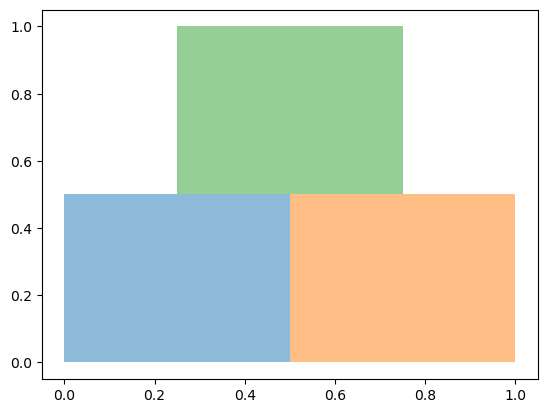

In [7]:
show_transformation(rules1)